# Clusterização Espacial de Solos com Machine Learning
## Aplicação para Apoio à Decisão Agrícola
Este notebook apresenta a construção do conjunto de dados de solos utilizado neste projeto. Os rasters de propriedades do solo obtidos do banco de dados SoilGrids são processados e convertidos em um conjunto de dados tabulares adequado para análises exploratórias e aplicações de aprendizado de máquina.

![image (imagem ilustrativa)](image.png)
**Nota:** Imagem gerada por Inteligência Artificial, utilizada exclusivamente para fins ilustrativos e educacionais.

## Contexto

O solo é um dos principais determinantes da produtividade agrícola. Suas propriedades físico-químicas influenciam diretamente a retenção de água, disponibilidade de nutrientes, desenvolvimento radicular e eficiência do manejo.

No agronegócio moderno, a segmentação territorial baseada em dados permite:

- Planejamento agrícola mais eficiente                    
- Otimização de insumos                    
- Redução de custos                
- Manejo localizado                
- Agricultura de precisão               

Neste contexto, técnicas de Aprendizado Não Supervisionado podem ser utilizadas para identificar padrões ocultos nos atributos do solo, permitindo a delimitação de zonas homogêneas com comportamento semelhante.

## Objetivo do Projeto

O objetivo deste projeto é aplicar técnicas de clusterização para identificar regiões com perfis edáficos semelhantes a partir de atributos físico-químicos do solo.                    
Busca-se responder à seguinte pergunta:                                  
**É possível identificar zonas homogêneas de solo utilizando técnicas de aprendizado não supervisionado?**

## Base de Dados

### Fonte dos dados

Os dados utilizados são provenientes do SoilGrids, base global de informações edáficas em formato raster, desenvolvida pelo ISRIC (International Soil Reference and Information Centre).
O SoilGrids fornece estimativas espaciais de propriedades físicas e químicas do solo em escala global, permitindo análises multivariadas de perfil edáfico.
Para este projeto, foi realizada amostragem do conjunto original (≈32 milhões de registros), reduzido para 50.000 observações, visando viabilidade computacional sem perda significativa de representatividade espacial.

### Área de estudo

Este projeto utiliza dados de propriedades do solo derivados de rasters globais, porém a análise foi restrita a um recorte espacial específico da América do Sul. A área de estudo foi delimitada entre as coordenadas:

- **Latitude:** -25 a -14                                       
- **Longitude:** -55 a -39                                  

Esse recorte espacial foi aplicado durante o processamento dos rasters, permitindo focar a análise em uma região com características pedológicas e ambientais relativamente homogêneas. A seleção dessa área também contribui para reduzir o volume de dados processados e facilitar a exploração dos padrões espaciais das propriedades do solo.

### Camada de profundidade do solo analisada

As propriedades do solo utilizadas neste estudo foram extraídas de rasters cuja nomenclatura inclui a indicação da profundidade da camada analisada. Os arquivos utilizados apresentam o sufixo 0-5cm_mean.tif, indicando que os valores representam estimativas médias das propriedades do solo na camada superficial entre 0 e 5 cm de profundidade.

Essa camada corresponde à porção mais superficial do solo, frequentemente associada a processos importantes como o acúmulo de matéria orgânica, a ciclagem de nutrientes e a interação direta com a vegetação e os microrganismos do solo. Dessa forma, a análise realizada neste projeto concentra-se nas características pedológicas dessa camada superficial.

### Variáveis Selecionadas

Para construir uma segmentação mais realista dos perfis de solo, foram incluídas variáveis que representam dimensões químicas e físicas do sistema edáfico:

**Propriedades químicas**

- pH do solo
- Carbono Orgânico do Solo (SOC)
- Nitrogênio Total (N total)
- Capacidade de Troca Catiônica (CTC)

**Propriedades físicas**

- Teor de Argila (Clay)
- Teor de Areia (Sand)
- Teor de Silte (Silt)
- Densidade Aparente (Bulk Density – BD)


#### Justificativa
A seleção das variáveis foi fundamentada na representação integrada dos principais fatores que determinam o comportamento agronômico do solo:

- **pH** influencia diretamente a disponibilidade de nutrientes e atividade microbiana.
- **SOC** está associado à fertilidade, estabilidade estrutural e retenção de água.
- **Nitrogênio total** representa potencial nutricional.
- **CTC** indica capacidade do solo em reter e trocar cátions essenciais.
- **Clay, Sand e Silt** definem a textura do solo, impactando retenção hídrica, drenagem e aeração.
- **Bulk Density** está relacionada à compactação e porosidade.

Essa abordagem multivariada permite uma segmentação mais robusta dos perfis edáficos, considerando simultaneamente fertilidade, textura e estrutura do solo.

## Importação das bibliotecas

In [1]:
import numpy as np
import pandas as pd
import rasterio
import matplotlib.pyplot as plt

## Definição dos arquivos raster

In [2]:
files = {
    "pH": "phh2o_0-5cm_mean.tif",
    "soc": "soc_0-5cm_mean.tif",
    "nitrogen": "nitrogen_0-5cm_mean.tif",
    "cec": "cec_0-5cm_mean.tif",
    "clay": "clay_0-5cm_mean.tif",
    "sand": "sand_0-5cm_mean.tif",
    "silt": "silt_0-5cm_mean.tif",
    "bd": "bdod_0-5cm_mean.tif"
}

## Leitura dos rasters

In [4]:
# Abrir rasters
datasets = {k: rasterio.open(v) for k, v in files.items()}

# Ler bandas com arrays numéricos
arrays = {k: ds.read(1).astype(float) for k, ds in datasets.items()}

# Empilhar variáveis → [linha, coluna, variável]
stacked = np.stack([arrays[k] for k in files.keys()], axis=-1)

#### Insight para Interpretação do empilhamento dos rasters

Nesta etapa, os diferentes rasters do solo foram combinados em uma única estrutura de dados.                         
Cada raster representa uma variável específica (como pH, carbono orgânico, textura, entre outras), organizada como uma matriz de valores no espaço geográfico.                                
Ao empilhar essas matrizes, foi criada uma estrutura tridimensional onde, para cada posição do mapa, temos um conjunto completo de atributos do solo.
Isso significa que cada pixel deixa de representar apenas um valor isolado e passa a conter um vetor de características, permitindo a análise conjunta das variáveis.                                       
Essa estrutura permite tratar cada pixel como uma observação multivariada, viabilizando a aplicação de métodos estatísticos e de aprendizado de máquina.

### Extração das coordenadas geográficas

In [11]:
# Seleciona um raster de referência para obter informações espaciais
ds_ref = list(datasets.values())[0]
transform = ds_ref.transform

# Dimensões do raster (linhas e colunas)
height = ds_ref.height
width = ds_ref.width

# Criar grade de índices (posição dos pixels)
rows, cols = np.meshgrid(np.arange(height), np.arange(width), indexing='ij')

# Converter índices de pixels em coordenadas geográficas (longitude e latitude)
xs, ys = rasterio.transform.xy(transform, rows, cols)

# Converter listas para arrays NumPy
lon = np.array(xs)
lat = np.array(ys)

# Verificar dimensões do array empilhado
height_s, width_s, n_variaveis = stacked.shape

# Combinar longitude e latitude em uma única estrutura
coords = np.stack([lon, lat], axis=-1)

# Garantir consistência das dimensões
height, width, _ = stacked.shape

# Visualizar formato do array (linha, coluna, variável)
stacked.shape

(4603, 7078, 8)

In [12]:
# Reestruturar os dados para formato tabular (Machine Learning)
# Cada pixel vira uma linha e cada variável uma coluna
X = stacked.reshape(-1, n_variaveis)
X.shape

(32580034, 8)

#### Interpretação da transformação espacial e estruturação dos dados
Os rasters armazenam informações em forma de grade (pixels), mas para análise é necessário relacionar esses valores com posições reais no espaço.    
A partir da matriz de transformação, cada pixel é convertido em coordenadas geográficas, permitindo mapear os dados para o mundo real, onde os dados são reorganizados para que cada ponto do espaço seja representado por um vetor de variáveis do solo.         

## Fechar rasters

In [13]:
for ds in datasets.values():
    ds.close()

#### Justificativa
Após a leitura dos dados, os arquivos raster são explicitamente fechados para liberar recursos do sistema, evitando consumo excessivo de memória e possíveis erros relacionados a arquivos abertos.

## Conversão raster para DataFrame

In [14]:
df = pd.DataFrame({
    "longitude": lon.flatten(),
    "latitude": lat.flatten(),
    "pH": arrays["pH"].flatten(),
    "SOC": arrays["soc"].flatten(),
    "Nitrogen": arrays["nitrogen"].flatten(),
    "CTC": arrays["cec"].flatten(),
    "Clay": arrays["clay"].flatten(),
    "Sand": arrays["sand"].flatten(),
    "Silt": arrays["silt"].flatten(),
    "Bulk_Density": arrays["bd"].flatten()
})

df

,longitude,latitude,pH,SOC,Nitrogen,CTC,Clay,Sand,Silt,Bulk_Density
0,-54.998870,-14.001195,50.0,189.0,141.0,94.0,214.0,501.0,285.0,125.0
1,-54.996609,-14.001195,51.0,172.0,139.0,93.0,222.0,503.0,275.0,122.0
2,-54.994349,-14.001195,51.0,198.0,150.0,98.0,205.0,503.0,292.0,116.0
3,-54.992088,-14.001195,51.0,198.0,150.0,98.0,205.0,503.0,292.0,116.0
4,-54.989828,-14.001195,51.0,195.0,155.0,101.0,201.0,507.0,292.0,114.0
...,...,...,...,...,...,...,...,...,...,...
32580029,-39.010172,-24.998805,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
32580030,-39.007912,-24.998805,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
32580031,-39.005651,-24.998805,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
32580032,-39.003391,-24.998805,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## Exploração inicial dos dados

### Visualização raster bruto

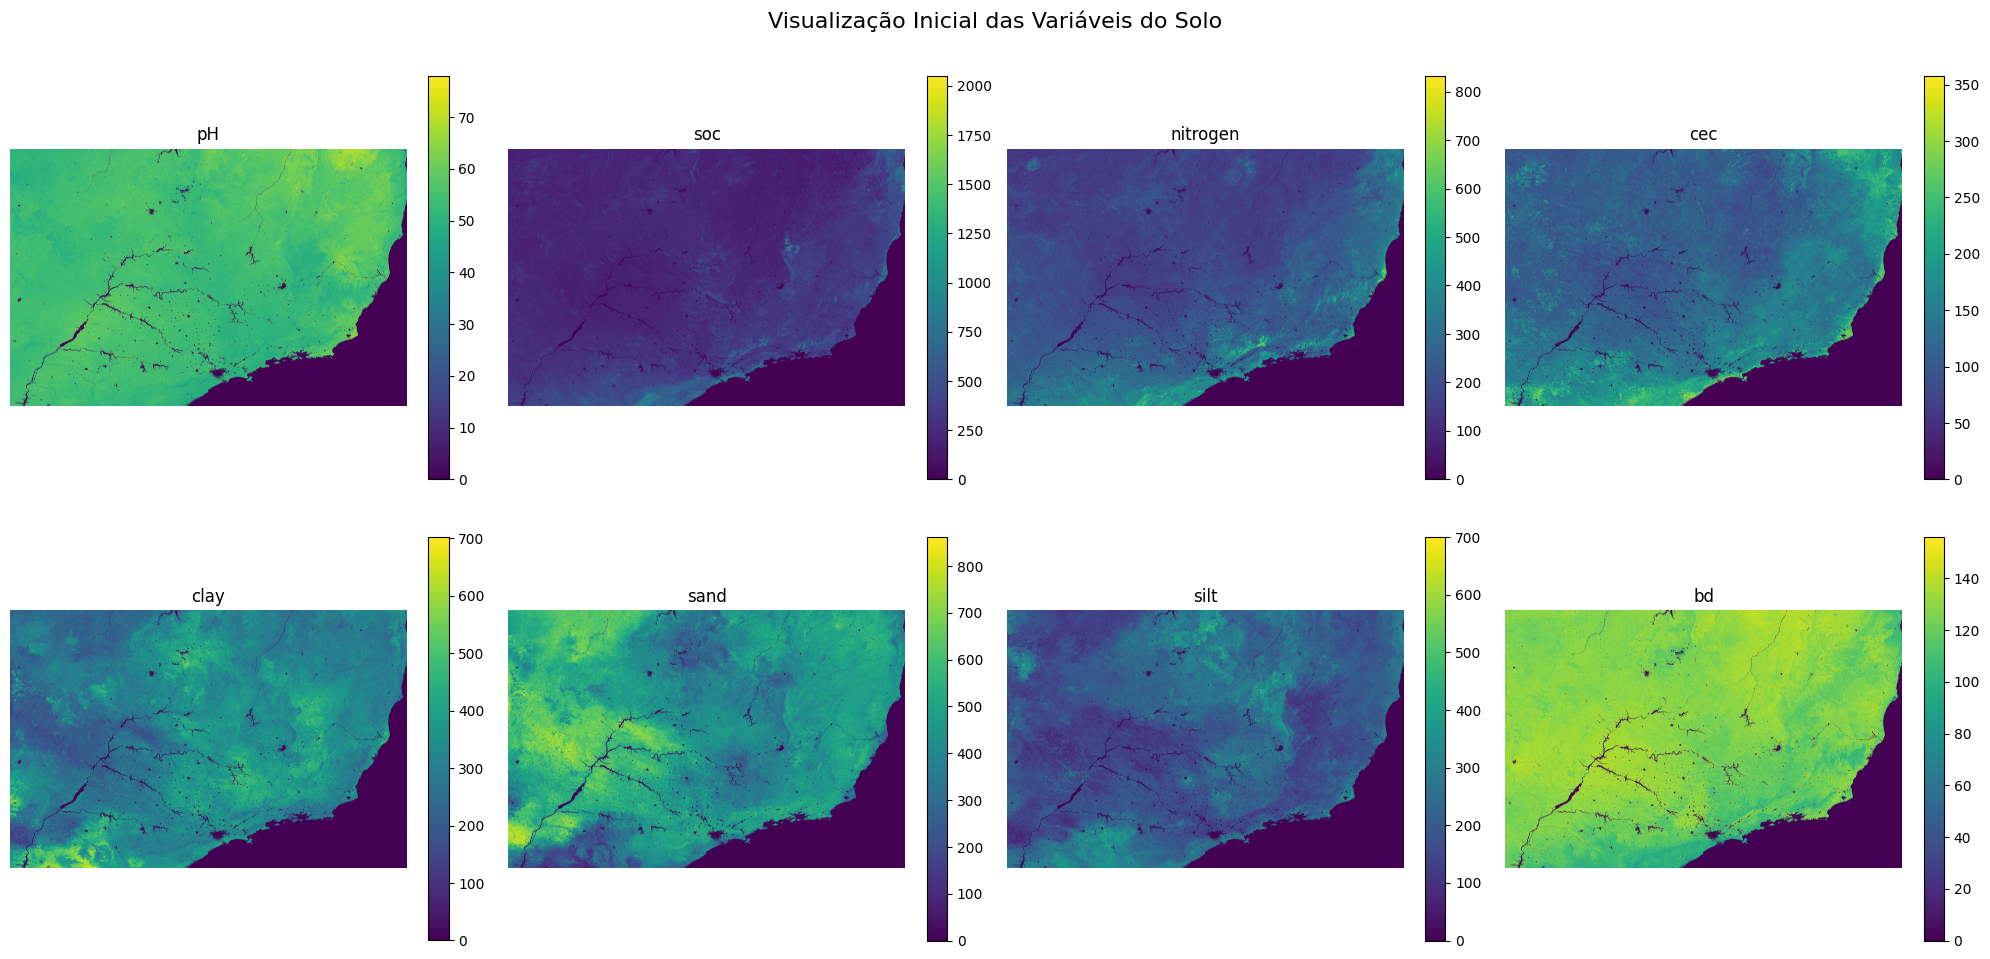

In [16]:
fig, axes = plt.subplots(2, 4, figsize=(20, 10))

axes = axes.flatten()  # transformar matriz 2x4 em lista linear

for ax, name in zip(axes, ["pH", "soc", "nitrogen", "cec",
                           "clay", "sand", "silt", "bd"]):
    
    im = ax.imshow(arrays[name], cmap="viridis")
    ax.set_title(name)
    ax.axis("off")
    plt.colorbar(im, ax=ax, fraction=0.046)

plt.suptitle("Visualização Inicial das Variáveis do Solo", fontsize=16)
plt.tight_layout()
plt.show()

#### Insight interpretação dos padrões espaciais

Os mapas evidenciam que as propriedades do solo apresentam forte variabilidade espacial, refletindo a influência de fatores ambientais e processos de formação do solo.                      
A presença de padrões contínuos e regiões com características semelhantes sugere que o solo pode ser segmentado em zonas com comportamentos distintos.
Além disso, a análise visual indica que algumas variáveis apresentam padrões espaciais semelhantes em determinadas regiões, o que pode sugerir possíveis relações entre atributos do solo.
No entanto, essa hipótese requer validação por meio de análises quantitativas, como correlação ou técnicas multivariadas.

### Verificar distribuição inicial

In [17]:
print(df.describe().apply(lambda s: s.apply('{0:.2f}'.format)))

         longitude     latitude           pH          SOC     Nitrogen  \
count  32580034.00  32580034.00  32580034.00  32580034.00  32580034.00   
mean        -47.00       -19.50        46.59       244.01       186.46   
std           4.62         3.18        19.37       143.87       102.41   
min         -55.00       -25.00         0.00         0.00         0.00   
25%         -51.00       -22.25        51.00       188.00       148.00   
50%         -47.00       -19.50        54.00       234.00       184.00   
75%         -43.00       -16.75        56.00       317.00       242.00   
max         -39.00       -14.00        78.00      2051.00       833.00   

               CTC         Clay         Sand         Silt Bulk_Density  
count  32580034.00  32580034.00  32580034.00  32580034.00  32580034.00  
mean        113.02       273.65       405.04       176.36       107.06  
std          58.31       129.84       194.49        92.52        44.78  
min           0.00         0.00         0

#### Insight
Os dados utilizados neste projeto foram obtidos do banco global SoilGrids, que armazena variáveis pedológicas em formato raster. Para otimização de armazenamento e padronização interna, algumas variáveis são disponibilizadas com fatores de escala (multiplicadas por 10 ou 100) ou em unidades alternativas (decigramas ou centigramas).

A verificação estatística inicial (describe()) revelou valores incompatíveis com as faixas normalmente observadas na literatura pedológica, indicando a necessidade de correção de escala.

A presença de valores iguais a zero no conjunto de dados não representa concentrações reais, mas sim pixels classificados como NoData. Esses registros estão provavelmente associados a corpos d’água, áreas urbanizadas ou bordas do recorte espacial. Considerando que a área de estudo inclui regiões costeiras e áreas com presença de corpos d’água e ocupação urbana, essa ocorrência é espacialmente coerente. Como valores nulos para variáveis como pH, carbono orgânico e nitrogênio são fisicamente implausíveis, a exclusão desses pixels é necessária para garantir consistência pedológica e maior confiabilidade nas análises e na clusterização subsequente.

## Limpeza dos dados

### Criar máscara de validade

In [18]:
soil_cols = [
    "pH", "SOC", "Nitrogen", "CTC",
    "Clay", "Sand", "Silt", "Bulk_Density"
]

mask = (df[soil_cols] > 0).all(axis=1)

### Aplicar filtro

In [19]:
df_valid = df[mask].copy()

In [20]:
# Conferindo dados restantes
print("Total original:", len(df))
print("Total válido:", len(df_valid))

Total original: 32580034
Total válido: 27857462


### Visualização raster filtrado

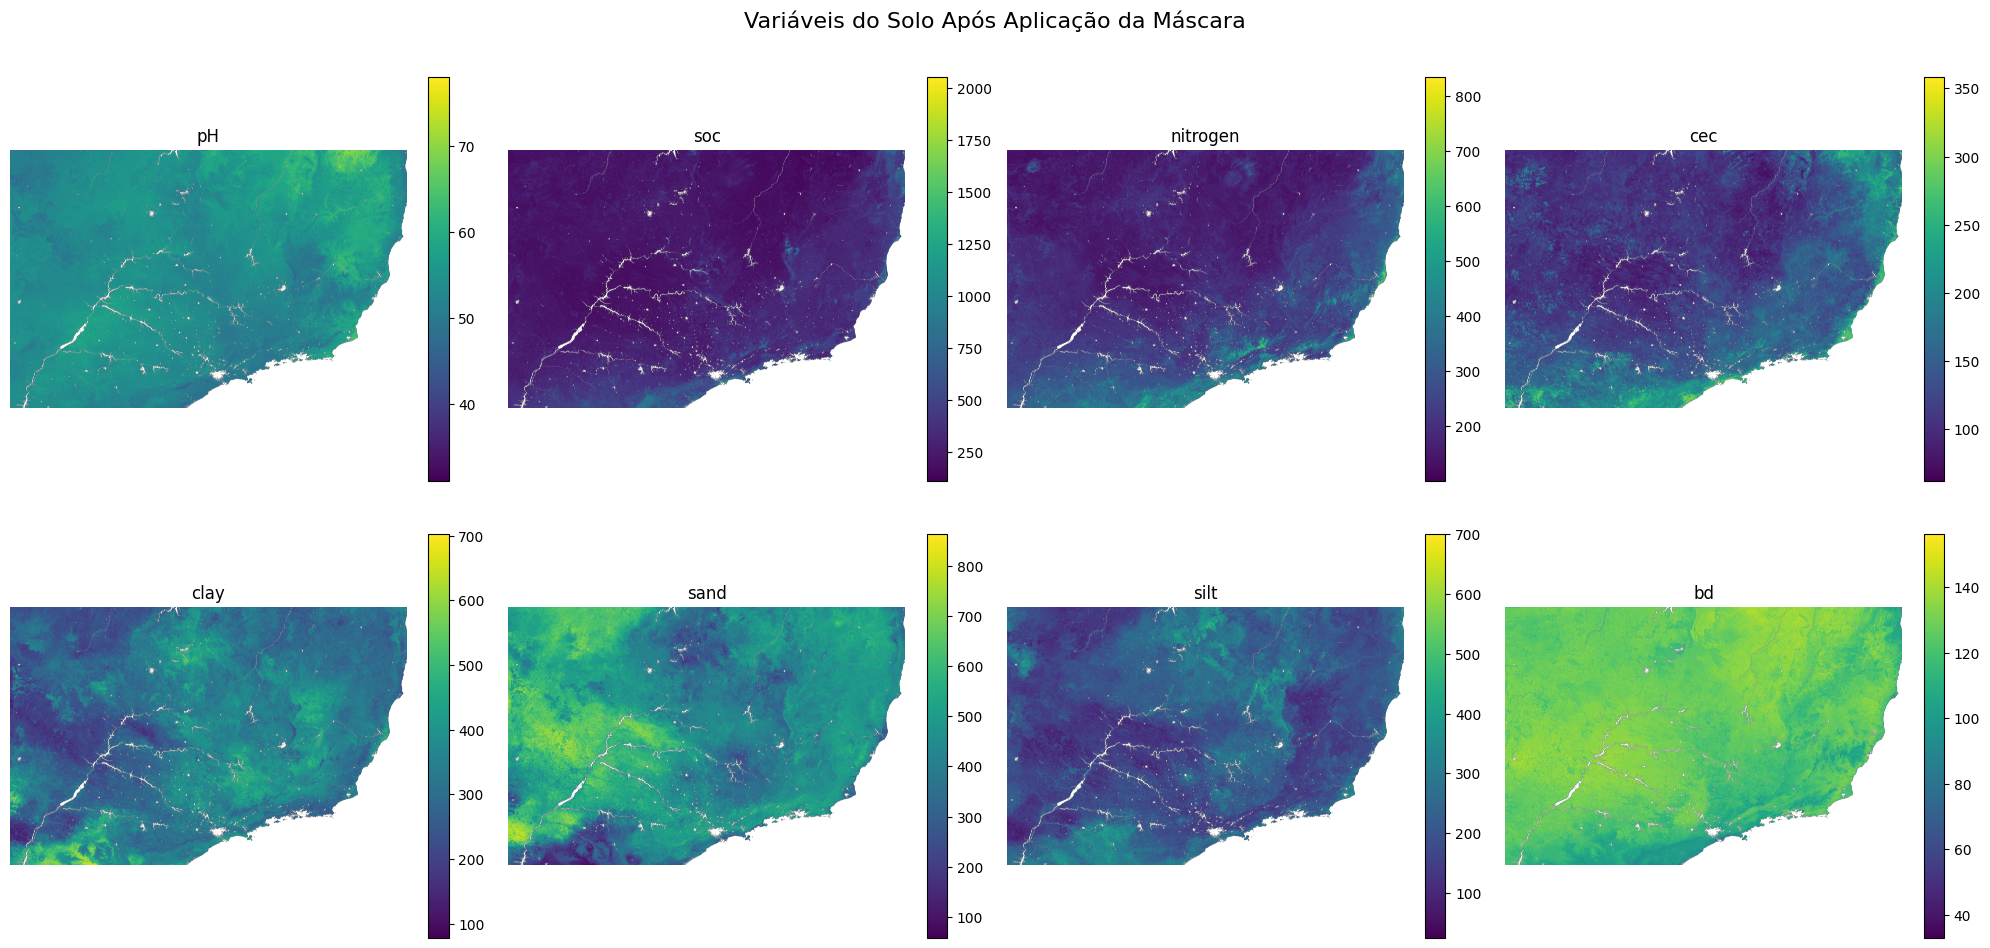

In [21]:
# Criar máscara 2D
mask_2d = (
    (arrays["pH"] > 0) &
    (arrays["soc"] > 0) &
    (arrays["nitrogen"] > 0) &
    (arrays["cec"] > 0) &
    (arrays["clay"] > 0) &
    (arrays["sand"] > 0) &
    (arrays["silt"] > 0) &
    (arrays["bd"] > 0)
)

mask_2d = np.ones_like(arrays["pH"], dtype=bool)

for key in arrays.keys():
    mask_2d &= (arrays[key] > 0)

# Aplicar máscara nos rasters
filtered_arrays = {}

for name in arrays.keys():
    filtered_arrays[name] = np.where(mask_2d, arrays[name], np.nan)

# Visualizar após máscara
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for ax, name in zip(axes, arrays.keys()):
    im = ax.imshow(filtered_arrays[name], cmap="viridis")
    ax.set_title(name)
    ax.axis("off")
    plt.colorbar(im, ax=ax, fraction=0.046)

plt.suptitle("Variáveis do Solo Após Aplicação da Máscara", fontsize=16)
plt.tight_layout()
plt.show()

### Conclusão
A aplicação da máscara (>0 para todas as variáveis) resultou na remoção de aproximadamente 15% dos pixels, concentrados principalmente em áreas costeiras e regiões associadas a ausência de dados válidos.

A inspeção visual indica que os principais padrões espaciais das variáveis foram mantidos após a filtragem, sugerindo que o processo removeu predominantemente ruído e valores inconsistentes.

Além disso, as distribuições das variáveis tornaram-se mais coerentes com os intervalos esperados para propriedades do solo, aumentando a confiabilidade do conjunto de dados para análises subsequentes.

## Amostragem dos dados

In [22]:
df_sample = df_valid.sample(
    n=50000,
    random_state=42
)

## Ajuste de escala das variáveis

Algumas variáveis presentes nos rasters são armazenadas utilizando fatores de escala (scale factors). Nesse tipo de armazenamento, os valores reais são multiplicados por um fator constante antes de serem gravados no raster. Essa estratégia é amplamente utilizada em bases geoespaciais para reduzir o tamanho dos arquivos e evitar o uso de números decimais, armazenando os dados como inteiros.

Para recuperar os valores nas unidades originais das propriedades do solo, é necessário aplicar a correção do fator de escala correspondente a cada variável. Assim, foram realizadas as seguintes transformações:

In [23]:
df_sample["pH"] = df_sample["pH"] / 10
df_sample["SOC"] = df_sample["SOC"] / 10
df_sample["Nitrogen"] = df_sample["Nitrogen"] / 100
df_sample["Bulk_Density"] = df_sample["Bulk_Density"] / 100

## Avaliação da consistência da textura do solo

In [24]:
# Criar variável soma
df_sample["texture_sum"] = (
    df_sample["Clay"] +
    df_sample["Sand"] +
    df_sample["Silt"]
)

In [25]:
# Estatística descritiva da soma
df_sample["texture_sum"].describe()

count    50000.000000
mean       999.998500
std          0.500303
min        999.000000
25%       1000.000000
50%       1000.000000
75%       1000.000000
max       1001.000000
Name: texture_sum, dtype: float64

In [26]:
# Avaliar desvio em relação a 100
df_sample["texture_error"] = df_sample["texture_sum"] - 1000
df_sample["texture_error"].describe()

count    50000.000000
mean        -0.001500
std          0.500303
min         -1.000000
25%          0.000000
50%          0.000000
75%          0.000000
max          1.000000
Name: texture_error, dtype: float64

In [27]:
# Percentual de pixels fora do intervalo aceitável
valid_texture = df_sample[
    (df_sample["texture_sum"] >= 999) &
    (df_sample["texture_sum"] <= 1001)
]

percent_ok = len(valid_texture) / len(df_sample) * 100
print(f"Percentual coerente (999 - 1001): {percent_ok:.2f}%")

Percentual coerente (999 - 1001): 100.00%


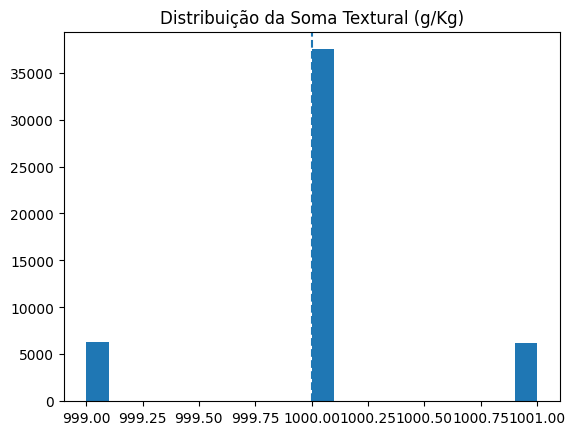

In [28]:
# Visualizar distribuição
plt.hist(df_sample["texture_sum"], bins=20)
plt.axvline(1000, linestyle="--")
plt.title("Distribuição da Soma Textural (g/Kg)")
plt.show()

#### Conclusão
A variável texture_sum apresentou média próxima de 1000 g/kg, desvio-padrão de apenas 0,5 g/kg e variação restrita ao intervalo de 999 a 1001 g/kg, indicando fechamento granulométrico praticamente exato entre areia, silte e argila. O histograma confirma forte concentração em torno de 1000 g/kg, com dispersão mínima e valores discretos, evidenciando alta consistência interna e ausência de ruído estrutural relevante, além de indicar correto balanceamento textural e padronização na unidade g/kg. Esse comportamento demonstra adequada padronização dos dados e robustez para uso em análises multivariadas subsequentes, como clusterização ou redução de dimensionalidade.

In [29]:
# Excluindo as colunas texture_sum e texture_error do dataset
df_sample = df_sample.drop(columns=["texture_sum", "texture_error"])

## Salvar dataset para análises posteriores

In [30]:
df_sample.to_csv("df_sample_soilgrids.csv", index=False)